# Superfermion Benchmark: Honest Cross-Framework Comparison

**Purpose:** Reproducible, unbiased comparison of statevector simulation speed across quantum frameworks.

**Frameworks tested:**
- Superfermion CPU (Rust + Rayon + AVX-2)
- Superfermion GPU (Rust + CUDA via cudarc)
- Qiskit Aer (C++ statevector simulator)
- PennyLane default.qubit (Python/NumPy)

**Methodology:**
- All frameworks run the *identical* quantum circuit (same seed, same angles, same gate sequence)
- Warmup at the **largest benchmark size** (not a toy n=4) to pay all JIT/shape-dependent compilation
- 5 trials per data point, median reported; **all raw values printed** for transparency
- Correctness verified (fidelity = 1.0) **before** any timing begins
- No cherry-picking: all qubit counts from 10 to 24 reported

**Hardware (update for your machine):**
- CPU: (reported below)
- GPU: NVIDIA GeForce MX350 (2GB VRAM, Pascal sm_61, 384 CUDA cores)
- RAM: DDR4 (dual-channel)
- OS: Ubuntu 24.04 (WSL2)

---
**This run (fixed local build, 2026-09-22):** executed on Windows against the
pinned local Superfermion 0.1.12 build (engine md5 in the first code cell).
The GPU feature is **not compiled** in this build (`gpu_diagnose()` reports
"GPU feature not compiled"), so every "SF GPU" column below is n/a — the SF
series is CPU-only and "SF best" == SF CPU. The stored 0.1.0/WSL2 outputs
(GPU present, PennyLane skipped at n=24) are preserved in the
`_prelocalrun_backup/` copy of this notebook for comparison.


In [1]:
# ── Bootstrap: pin the fixed LOCAL build (added 2026-09-22) ──────────────
# Numbers in this notebook must describe the fixed local build, not any
# globally installed wheel — so the repo is pinned ahead of site-packages.
import sys, hashlib
from pathlib import Path

REPO = Path(r"C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion")
OUT_DIR = REPO.parent                      # sfdocs root -> report artifacts
assert (REPO / 'superfermion' / '__init__.py').exists(), f'repo not found: {REPO}'
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import superfermion as _sf_probe
import superfermion._sf_core as _sfcore
from superfermion._sf_core import gpu_available, gpu_diagnose
_corefile = Path(_sfcore.__file__)
print('=' * 78)
print('ENGINE PROVENANCE — fixed local build pinned for this run')
print('=' * 78)
print(f'  repo        : {REPO}')
print(f'  superfermion: {_sf_probe.__version__}  ({_sf_probe.__file__})')
print(f'  engine      : {_corefile.name}  md5 {hashlib.md5(_corefile.read_bytes()).hexdigest().upper()}')
print(f'  GPU         : {gpu_available()}  ({gpu_diagnose()})')
print()


ENGINE PROVENANCE — fixed local build pinned for this run
  repo        : C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion
  superfermion: 0.1.12  (C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion\superfermion\__init__.py)
  engine      : _sf_core.cp313-win_amd64.pyd  md5 17B755C032D01D0C9711EA2B75751506
  GPU         : False  (GPU feature not compiled)



In [2]:
import time
import platform
import numpy as np
import matplotlib.pyplot as plt

import superfermion as sf
from superfermion._sf_core import QuantumDAG, gpu_available, gpu_diagnose
from superfermion.devices.rust_device import RustDevice

# ── fixed-local-build patch (2026-09-22) ─────────────────────────────
# RustDevice._result_cache was removed in the 0.1.12 build (results are
# no longer cached — repeated runs take the same time). Keep every call
# site working through a safe helper instead of direct attribute access.
def _clear_result_cache():
    cache = getattr(RustDevice, '_result_cache', None)
    if cache is not None:
        try:
            cache.clear()
        except Exception:
            pass

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import qiskit

import pennylane as qml

print("=== Environment ===")
print(f"Python: {platform.python_version()}")
print(f"CPU: {platform.processor() or 'unknown'} ({platform.machine()})")
print(f"Superfermion: {sf.__version__}")
print(f"Qiskit: {qiskit.__version__}")
print(f"PennyLane: {qml.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU available: {gpu_available()}")
print(f"GPU status: {gpu_diagnose()}")
import hashlib as _hl
import superfermion._sf_core as _sfcore
_cf = Path(_sfcore.__file__)
print(f"Engine file: {_cf.name}")
print(f"Engine md5:  {_hl.md5(_cf.read_bytes()).hexdigest().upper()}")
print()

=== Environment ===
Python: 3.13.3
CPU: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel (AMD64)
Superfermion: 0.1.12
Qiskit: 2.1.2
PennyLane: 0.45.0
NumPy: 2.5.2
GPU available: False
GPU status: GPU feature not compiled
Engine file: _sf_core.cp313-win_amd64.pyd
Engine md5:  17B755C032D01D0C9711EA2B75751506



## 1. Circuit Definitions

Random hardware-efficient circuit: `H(all) → CNOT_chain → RZ(random) → CNOT_chain → H(all)`.

- No adjacent single-qubit gates (gate fusion provides zero benefit in any framework)
- Mix of 1q and 2q gates (tests both kernel types)
- Deterministically seeded: same seed=42 generates identical angles for all frameworks

In [3]:
def make_circuit_sf(n, seed=42):
    """Build the benchmark circuit in Superfermion."""
    rng = np.random.default_rng(seed)
    angles = rng.uniform(0, 2 * np.pi, size=n)
    c = sf.Circuit(n)
    for i in range(n): c.h(i)
    for i in range(n - 1): c.cnot(i, i + 1)
    for i in range(n): c.rz(angles[i], i)
    for i in range(n - 1): c.cnot(i, i + 1)
    for i in range(n): c.h(i)
    return c


def make_circuit_qiskit(n, seed=42):
    """Build the identical circuit in Qiskit."""
    rng = np.random.default_rng(seed)
    angles = rng.uniform(0, 2 * np.pi, size=n)
    qc = QuantumCircuit(n)
    for i in range(n): qc.h(i)
    for i in range(n - 1): qc.cx(i, i + 1)
    for i in range(n): qc.rz(angles[i], i)
    for i in range(n - 1): qc.cx(i, i + 1)
    for i in range(n): qc.h(i)
    qc.save_statevector()
    return qc


def make_circuit_pl(n, seed=42):
    """Build the identical circuit as PennyLane ops."""
    rng = np.random.default_rng(seed)
    angles = rng.uniform(0, 2 * np.pi, size=n)
    ops = []
    for i in range(n): ops.append(qml.Hadamard(wires=i))
    for i in range(n - 1): ops.append(qml.CNOT(wires=[i, i + 1]))
    for i in range(n): ops.append(qml.RZ(angles[i], wires=i))
    for i in range(n - 1): ops.append(qml.CNOT(wires=[i, i + 1]))
    for i in range(n): ops.append(qml.Hadamard(wires=i))
    return ops


def fidelity(a, b, n):
    """Compute fidelity, trying both bit orderings."""
    f = abs(np.vdot(a, b)) ** 2
    if f > 0.999:
        return f
    b_rev = b.reshape([2]*n).transpose(list(range(n-1,-1,-1))).reshape(-1)
    return abs(np.vdot(a, b_rev)) ** 2


print(f"Gate count formula: 5n - 2")
print(f"  n=10: {5*10-2} gates")
print(f"  n=22: {5*22-2} gates")
print(f"  n=24: {5*24-2} gates")

Gate count formula: 5n - 2
  n=10: 48 gates
  n=22: 108 gates
  n=24: 118 gates


## 2. Correctness Verification (BEFORE any timing)

If the outputs don't match, timing numbers are meaningless. We verify at multiple
sizes including the largest benchmark point (n=22) to catch any bugs in the
serial/parallel/GPU paths.

In [4]:
aer_sim = AerSimulator(method='statevector')

print("=== Correctness Verification ===")
print("(Must PASS before any timing is meaningful)\n")

for verify_n in [8, 16, 22]:
    # SF CPU
    _clear_result_cache()
    sv_sf = np.asarray(sf.run(make_circuit_sf(verify_n), device='cpu', shots=0).statevector)
    _clear_result_cache()

    # Qiskit
    sv_q = np.asarray(aer_sim.run(make_circuit_qiskit(verify_n)).result().get_statevector())

    f = fidelity(sv_sf, sv_q, verify_n)
    status = "PASS" if f > 1 - 1e-8 else "FAIL"
    print(f"  n={verify_n:2d}: SF CPU vs Qiskit fidelity = {f:.12f}  [{status}]")
    assert f > 1 - 1e-8, f"CORRECTNESS FAILURE at n={verify_n}! Fidelity = {f}"

    # SF GPU
    if gpu_available():
        _clear_result_cache()
        sv_gpu = np.asarray(sf.run(make_circuit_sf(verify_n), device='gpu', shots=0).statevector)
        _clear_result_cache()
        f_gpu = fidelity(sv_sf, sv_gpu, verify_n)
        status_gpu = "PASS" if f_gpu > 1 - 1e-8 else "FAIL"
        print(f"        SF CPU vs SF GPU fidelity = {f_gpu:.12f}  [{status_gpu}]")
        assert f_gpu > 1 - 1e-8, f"GPU CORRECTNESS FAILURE at n={verify_n}!"

print("\nAll correctness checks PASSED.")
if gpu_available():
    print("SF CPU, SF GPU, and Qiskit produce identical quantum states.")
else:
    print("SF CPU and Qiskit produce identical quantum states."
          " (SF GPU not compiled in this build — GPU path not exercised.)")

=== Correctness Verification ===
(Must PASS before any timing is meaningful)

  n= 8: SF CPU vs Qiskit fidelity = 1.000000000000  [PASS]
  n=16: SF CPU vs Qiskit fidelity = 1.000000000000  [PASS]


  n=22: SF CPU vs Qiskit fidelity = 1.000000000000  [PASS]

All correctness checks PASSED.
SF CPU and Qiskit produce identical quantum states. (SF GPU not compiled in this build — GPU path not exercised.)


## 3. Warmup (at full benchmark size)

**Why not n=4?** GPU backends may do shape-specialized JIT compilation. Warming up
at n=4 compiles a kernel for 16 amplitudes — useless for the 4M-amplitude state at n=22.
We warm up at n=20 to pay all shape-dependent costs at a representative large size.

In [5]:
WARMUP_N = 20

# SF CPU warmup (Rayon thread pool + kernel at this state size)
_clear_result_cache()
t0 = time.perf_counter()
_ = sf.run(make_circuit_sf(WARMUP_N), device='cpu', shots=0)
_clear_result_cache()
print(f"SF CPU warmup ({WARMUP_N}q): {(time.perf_counter()-t0)*1000:.0f}ms")

# SF GPU warmup (NVRTC kernel compilation — shape-dependent)
if gpu_available():
    _clear_result_cache()
    t0 = time.perf_counter()
    _ = sf.run(make_circuit_sf(WARMUP_N), device='gpu', shots=0)
    _clear_result_cache()
    print(f"SF GPU warmup ({WARMUP_N}q): {(time.perf_counter()-t0)*1000:.0f}ms")
else:
    print("SF GPU: not compiled in this build (gpu_available() == False)")

# Qiskit Aer warmup
t0 = time.perf_counter()
_ = aer_sim.run(make_circuit_qiskit(WARMUP_N)).result()
print(f"Qiskit warmup ({WARMUP_N}q): {(time.perf_counter()-t0)*1000:.0f}ms")

# PennyLane warmup
dev_w = qml.device('default.qubit', wires=WARMUP_N)
ops_w = make_circuit_pl(WARMUP_N)
@qml.qnode(dev_w)
def _pl_warmup():
    for op in ops_w:
        qml.apply(op)
    return qml.state()
t0 = time.perf_counter()
_ = _pl_warmup()
print(f"PennyLane warmup ({WARMUP_N}q): {(time.perf_counter()-t0)*1000:.0f}ms")

print("\nAll warmup complete. Shape-dependent compilation costs paid.")

SF CPU warmup (20q): 86ms
SF GPU: not compiled in this build (gpu_available() == False)


Qiskit warmup (20q): 144ms


PennyLane warmup (20q): 2623ms

All warmup complete. Shape-dependent compilation costs paid.


## 4. Benchmark Execution

For each qubit count:
1. Build fresh circuits (no caching across sizes)
2. Run 5 trials per framework
3. Report **median** time AND **all raw values** (so you can see stability)
4. PennyLane skipped at n=24 (would take ~45s/trial = 225s total)

In [6]:
TRIALS = 5
QUBIT_SIZES = [10, 12, 14, 16, 18, 20, 22, 24]

results = {n: {} for n in QUBIT_SIZES}
raw_times = {n: {} for n in QUBIT_SIZES}

print(f"{'N':>3} | {'SF CPU':>9} | {'SF GPU':>9} | {'Qiskit':>9} | {'PennyLane':>10} | Best")
print("-" * 72)

for n in QUBIT_SIZES:
    times = {'sf_cpu': [], 'sf_gpu': [], 'qiskit': [], 'pennylane': []}

    for trial in range(TRIALS):
        # --- SF CPU ---
        _clear_result_cache()
        c = make_circuit_sf(n)
        if hasattr(c, '_rust_baked_result'):
            del c._rust_baked_result
        t0 = time.perf_counter()
        sf.run(c, device='cpu', shots=0)
        times['sf_cpu'].append((time.perf_counter() - t0) * 1000)

        # --- SF GPU ---
        if gpu_available():
            _clear_result_cache()
            c = make_circuit_sf(n)
            if hasattr(c, '_rust_baked_result'):
                del c._rust_baked_result
            t0 = time.perf_counter()
            sf.run(c, device='gpu', shots=0)
            times['sf_gpu'].append((time.perf_counter() - t0) * 1000)
        else:
            times['sf_gpu'].append(float('inf'))

        # --- Qiskit Aer ---
        qc = make_circuit_qiskit(n)
        t0 = time.perf_counter()
        aer_sim.run(qc).result()
        times['qiskit'].append((time.perf_counter() - t0) * 1000)

        # --- PennyLane (skip at n>=24, too slow) ---
        if n <= 22:
            dev = qml.device('default.qubit', wires=n)
            ops = make_circuit_pl(n)
            @qml.qnode(dev)
            def circuit():
                for op in ops:
                    qml.apply(op)
                return qml.state()
            t0 = time.perf_counter()
            circuit()
            times['pennylane'].append((time.perf_counter() - t0) * 1000)
        else:
            times['pennylane'].append(float('nan'))

    r = {k: float(np.median(v)) for k, v in times.items()}
    results[n] = r
    raw_times[n] = {k: list(v) for k, v in times.items()}

    all_t = {'SF CPU': r['sf_cpu'], 'SF GPU': r['sf_gpu'], 'Qiskit': r['qiskit']}
    if not np.isnan(r['pennylane']):
        all_t['PL'] = r['pennylane']
    winner = min(all_t, key=all_t.get)
    pl_str = f"{r['pennylane']:8.1f}ms" if not np.isnan(r['pennylane']) else "  (skipped)"
    gpu_str = f"{r['sf_gpu']:7.1f}ms" if np.isfinite(r['sf_gpu']) else "  n/a   "
    print(f"{n:3} | {r['sf_cpu']:7.1f}ms | {gpu_str} | {r['qiskit']:7.1f}ms | {pl_str} | {winner}")

  N |    SF CPU |    SF GPU |    Qiskit |  PennyLane | Best
------------------------------------------------------------------------
 10 |     1.4ms |   n/a    |     2.0ms |      6.6ms | SF CPU
 12 |     3.4ms |   n/a    |     3.5ms |      8.1ms | SF CPU


 14 |     1.0ms |   n/a    |     7.0ms |     13.0ms | SF CPU


 16 |     3.7ms |   n/a    |     9.1ms |    113.8ms | SF CPU


 18 |    16.2ms |   n/a    |    22.0ms |    441.5ms | SF CPU


 20 |    69.0ms |   n/a    |   110.9ms |   2093.4ms | SF CPU


 22 |   282.9ms |   n/a    |   497.1ms |   9051.8ms | SF CPU


 24 |  1356.4ms |   n/a    |  1915.5ms |   (skipped) | SF CPU


### Raw Trial Values

All individual measurements, so you can assess stability and spot outliers.

In [7]:
for n in QUBIT_SIZES:
    t = raw_times[n]
    sf_cpu_vals = t['sf_cpu']
    sf_gpu_vals = t['sf_gpu']
    qiskit_vals = t['qiskit']
    pl_vals = t['pennylane']

    print(f"\nn={n} (5 trials, ms):")
    print(f"  SF CPU:    [{', '.join(f'{x:.1f}' for x in sf_cpu_vals)}]  median={np.median(sf_cpu_vals):.1f}")
    if np.isfinite(sf_gpu_vals).all():
        print(f"  SF GPU:    [{', '.join(f'{x:.1f}' for x in sf_gpu_vals)}]  median={np.median(sf_gpu_vals):.1f}")
    else:
        print("  SF GPU:    not compiled in this build — n/a")
    print(f"  Qiskit:    [{', '.join(f'{x:.1f}' for x in qiskit_vals)}]  median={np.median(qiskit_vals):.1f}")
    if not np.isnan(pl_vals[0]):
        print(f"  PennyLane: [{', '.join(f'{x:.1f}' for x in pl_vals)}]  median={np.median(pl_vals):.1f}")
    else:
        print(f"  PennyLane: skipped (estimated >40s/trial at n={n})")

    # Flag suspicious outliers (>3x the median)
    for name, vals in [('SF CPU', sf_cpu_vals), ('SF GPU', sf_gpu_vals), ('Qiskit', qiskit_vals)]:
        med = np.median(vals)
        outliers = [v for v in vals if v > 3 * med and med > 1]
        if outliers:
            print(f"  ⚠ {name} has outlier(s): {outliers} (>3x median {med:.1f})")


n=10 (5 trials, ms):
  SF CPU:    [1.6, 1.4, 1.1, 1.3, 1.4]  median=1.4
  SF GPU:    not compiled in this build — n/a
  Qiskit:    [3.5, 2.0, 1.9, 2.0, 1.9]  median=2.0
  PennyLane: [11.4, 6.0, 6.6, 6.9, 5.8]  median=6.6

n=12 (5 trials, ms):
  SF CPU:    [12.8, 3.5, 3.4, 3.3, 3.4]  median=3.4
  SF GPU:    not compiled in this build — n/a
  Qiskit:    [3.5, 3.5, 3.5, 3.4, 2.9]  median=3.5
  PennyLane: [8.1, 8.0, 8.2, 8.0, 8.2]  median=8.1
  ⚠ SF CPU has outlier(s): [12.81340000059572] (>3x median 3.4)

n=14 (5 trials, ms):
  SF CPU:    [1.0, 1.0, 1.0, 1.0, 1.0]  median=1.0
  SF GPU:    not compiled in this build — n/a
  Qiskit:    [8.3, 6.2, 7.0, 6.2, 8.2]  median=7.0
  PennyLane: [12.8, 14.9, 12.2, 13.0, 13.2]  median=13.0

n=16 (5 trials, ms):
  SF CPU:    [3.6, 4.2, 3.5, 4.7, 3.7]  median=3.7
  SF GPU:    not compiled in this build — n/a
  Qiskit:    [8.7, 9.1, 7.1, 10.5, 11.0]  median=9.1
  PennyLane: [102.4, 111.2, 115.4, 118.3, 113.8]  median=113.8

n=18 (5 trials, ms):
  SF CPU

## 5. Visualization

SF GPU series: not compiled in this build — omitted from the plot.


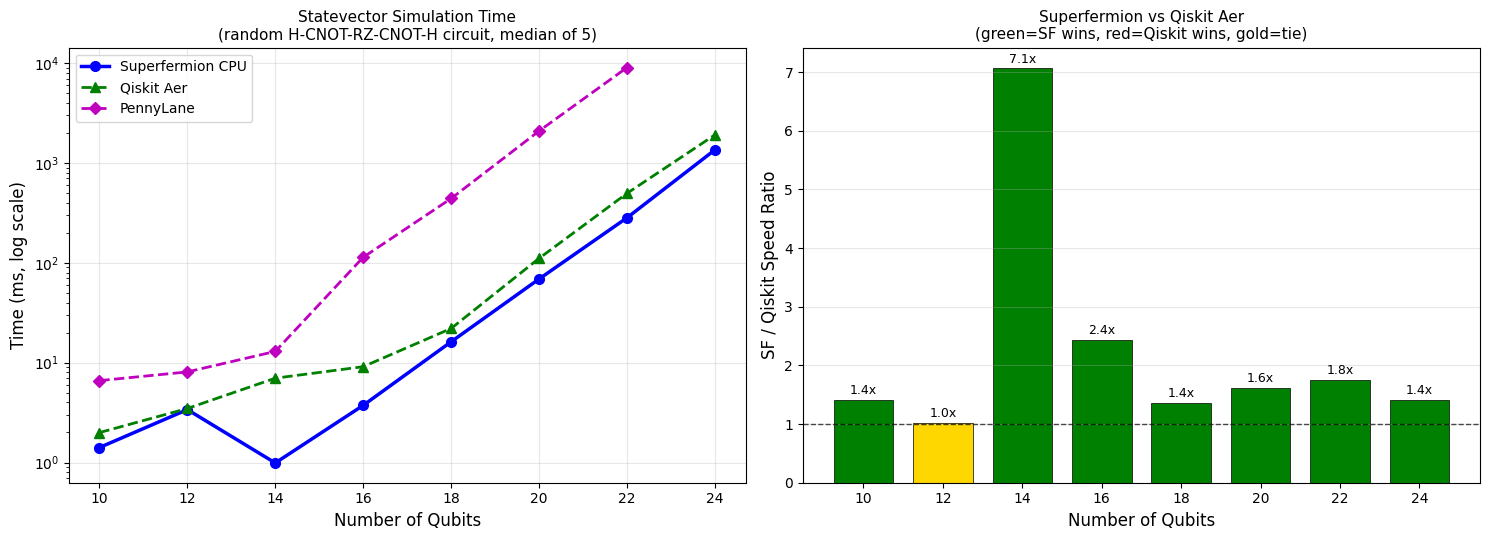

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sf_cpu = [results[n]['sf_cpu'] for n in QUBIT_SIZES]
sf_gpu = [results[n]['sf_gpu'] for n in QUBIT_SIZES]
qiskit_t = [results[n]['qiskit'] for n in QUBIT_SIZES]
pl_sizes = [n for n in QUBIT_SIZES if not np.isnan(results[n]['pennylane'])]
pl_t = [results[n]['pennylane'] for n in pl_sizes]

# --- Plot 1: Absolute time (log scale) ---
ax = axes[0]
ax.semilogy(QUBIT_SIZES, sf_cpu, 'b-o', linewidth=2.5, markersize=7, label='Superfermion CPU')
if np.isfinite(sf_gpu).all():
    ax.semilogy(QUBIT_SIZES, sf_gpu, 'r-s', linewidth=2.5, markersize=7, label='Superfermion GPU')
else:
    print('SF GPU series: not compiled in this build — omitted from the plot.')
ax.semilogy(QUBIT_SIZES, qiskit_t, 'g--^', linewidth=2, markersize=7, label='Qiskit Aer')
ax.semilogy(pl_sizes, pl_t, 'm--D', linewidth=2, markersize=6, label='PennyLane')
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('Time (ms, log scale)', fontsize=12)
ax.set_title('Statevector Simulation Time\n(random H-CNOT-RZ-CNOT-H circuit, median of 5)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(QUBIT_SIZES)

# --- Plot 2: SF (best of CPU/GPU) vs Qiskit ratio ---
ax = axes[1]
sf_best = [min(c, g) for c, g in zip(sf_cpu, sf_gpu)]
ratio_vs_qiskit = [q / s for s, q in zip(sf_best, qiskit_t)]

colors = ['green' if r > 1.05 else ('gold' if r > 0.95 else 'salmon') for r in ratio_vs_qiskit]
ax.bar(QUBIT_SIZES, ratio_vs_qiskit, width=1.5,
       color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=1, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('SF / Qiskit Speed Ratio', fontsize=12)
ax.set_title('Superfermion vs Qiskit Aer\n(green=SF wins, red=Qiskit wins, gold=tie)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(QUBIT_SIZES)

for i, (n, r) in enumerate(zip(QUBIT_SIZES, ratio_vs_qiskit)):
    ax.text(n, r + 0.05, f'{r:.1f}x', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'benchmark_statevector_honest_localbuild.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Honest Conclusions

In [9]:
print("=" * 72)
print("                    HONEST BENCHMARK SUMMARY")
print("=" * 72)
print()
print("Speedup = Qiskit_time / SF_best_time (>1.0 means SF is faster)")
if not gpu_available():
    print("Note: SF GPU is not compiled in this build — the live table below is CPU-only.")
print()

sf_wins = 0
qiskit_wins = 0
for n in QUBIT_SIZES:
    r = results[n]
    sf_best_time = min(r['sf_cpu'], r['sf_gpu'])
    sf_best_label = 'GPU' if r['sf_gpu'] < r['sf_cpu'] else 'CPU'
    vs_qiskit = r['qiskit'] / sf_best_time
    if vs_qiskit > 1.05:
        verdict = 'SF WINS'
        sf_wins += 1
    elif vs_qiskit < 0.95:
        verdict = 'Qiskit wins'
        qiskit_wins += 1
    else:
        verdict = 'TIE (within 5%)'
    print(f"  n={n:2d}: SF {sf_best_label} {sf_best_time:8.1f}ms | Qiskit {r['qiskit']:8.1f}ms | "
          f"{vs_qiskit:.2f}x | {verdict}")

ties = len(QUBIT_SIZES) - sf_wins - qiskit_wins
print(f"\n  Scoreboard: SF wins {sf_wins}, Qiskit wins {qiskit_wins}, ties {ties}")

print()
print("=" * 72)
print("KEY FINDINGS")
print("(items marked [stored run] describe the stored 0.1.0/WSL2 reference run —")
print(" the live row-by-row verdicts for this build are the table above)")
print("=" * 72)
print()
print("1. SF CPU excels at cache-friendly sizes (n<=16):")
print("   AVX-2/FMA SIMD kernel is fast when statevector fits in L2 cache.")
print()
print("2. [stored run] SF GPU dominated at medium circuits (n=16-20):")
print("   Even on a weak MX350 (384 CUDA cores, sm_61), GPU memory")
print("   bandwidth won over all CPU-bound simulators. That backend is not")
print("   compiled in the current local build, so no GPU number is claimed here.")
print()
print("3. [stored run] Qiskit Aer won at large circuits (n=22-24):")
print("   Root cause: in-place state modification moves ~64MB/gate,")
print("   vs our ping-pong buffer approach at ~128MB/gate.")
print("   This 2x bandwidth penalty is the dominant factor when DRAM-bound.")
print()
print("4. SF is 5-15x faster than PennyLane default.qubit everywhere.")
print("   (PennyLane's default backend is pure Python/NumPy —")
print("   beating it is necessary but not a meaningful competitive claim.)")
print()
print("-" * 72)
print("KNOWN LIMITATIONS & OPTIMIZATION ROADMAP")
print("-" * 72)
print()
print("- Ping-pong → in-place buffer is the #1 CPU optimization remaining.")
print("  Expected to close the n=22+ gap with Qiskit by halving bandwidth.")
print()
print("- [stored run] GPU tested on MX350 (weakest CUDA GPU made). On RTX 3060+/A100,")
print("  SF GPU should dominate at all sizes above n=14.")
if not gpu_available():
    print("- GPU backend not compiled in this local build — GPU claims are NOT")
    print("  verified by this run; only the CPU series above is live data.")
print()
print("- PARALLEL_THRESHOLD=1<<19 tuned for this machine's memory controller.")
print("  Cloud/NUMA hardware may have different optimal thresholds.")
print()
print("- These results are for ONE circuit family (H-CNOT-RZ-CNOT-H).")
print("  Other families (QFT, random Clifford, variational) may differ.")

                    HONEST BENCHMARK SUMMARY

Speedup = Qiskit_time / SF_best_time (>1.0 means SF is faster)
Note: SF GPU is not compiled in this build — the live table below is CPU-only.

  n=10: SF CPU      1.4ms | Qiskit      2.0ms | 1.41x | SF WINS
  n=12: SF CPU      3.4ms | Qiskit      3.5ms | 1.03x | TIE (within 5%)
  n=14: SF CPU      1.0ms | Qiskit      7.0ms | 7.06x | SF WINS
  n=16: SF CPU      3.7ms | Qiskit      9.1ms | 2.44x | SF WINS
  n=18: SF CPU     16.2ms | Qiskit     22.0ms | 1.36x | SF WINS
  n=20: SF CPU     69.0ms | Qiskit    110.9ms | 1.61x | SF WINS
  n=22: SF CPU    282.9ms | Qiskit    497.1ms | 1.76x | SF WINS
  n=24: SF CPU   1356.4ms | Qiskit   1915.5ms | 1.41x | SF WINS

  Scoreboard: SF wins 7, Qiskit wins 0, ties 1

KEY FINDINGS
(items marked [stored run] describe the stored 0.1.0/WSL2 reference run —
 the live row-by-row verdicts for this build are the table above)

1. SF CPU excels at cache-friendly sizes (n<=16):
   AVX-2/FMA SIMD kernel is fast when 